# Experiment Visualization from Training Logs

**This notebook is used for visualizing the experiments of LightGCN Torch Version, we have colllected the training logs (in .txt format) in all of the ipynbs inside the experiment folder with the same format structure and plotting necessary metrics into graph for better visualization**

**Read Log**

In [23]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorboard.backend.event_processing import event_accumulator
import zipfile



**We write a plotting function to visualize the 2 important metrics: Recall and NDCG as well as visualizing the system metrics performance base on the Training Log Pattern Extracted from the logs file**

**Example Training Log Sample**

`EPOCH[10/1000] loss0.105-|Sample:17.65| | T:37.68s | RAM:1774.7MB | CPU:10.7% | VRAM:126.4MB`

**We also utitlize the library to plot out metrics logs from tensorboard to get the recall and ndcg metrics**

In [24]:
def plot_all_metrics(
    log_txt_path: str,
    tensor_board_path: str,
    name: str = "",
):
    epochs = []
    losses = []
    ram_vals = []
    vram_vals = []

    title_prefix = os.path.splitext(os.path.basename(log_txt_path))[0] + " run"

    pattern = re.compile(
        r"EPOCH\[(\d+)/\d+\]"
        r".*?loss([\d.]+)"
        r".*?Sample:([\d.]+)"
        r".*?T:([\d.]+)s"
        r".*?RAM:([\d.]+)MB"
        r".*?CPU:([\d.]+)%"
        r".*?VRAM:([\d.]+)MB"
    )
    with open(log_txt_path, "r", encoding="utf-8") as fin:
        for line in fin:
            m = pattern.search(line)
            if not m:
                continue

            epochs.append(int(m.group(1)))
            losses.append(float(m.group(2)))
            ram_vals.append(float(m.group(5)))
            vram_vals.append(float(m.group(7)))

    avg_ram = np.mean(ram_vals)
    avg_vram = np.mean(vram_vals)

    print(f"Average System RAM : {avg_ram:.2f} MB")
    print(f"Average System VRAM: {avg_vram:.2f} MB")


    recall_dir = f"{tensor_board_path}/Test/Recall@[20]/20"
    ndcg_dir = f"{tensor_board_path}/Test/NDCG@[20]/20"

    ea_recall = event_accumulator.EventAccumulator(recall_dir)
    ea_recall.Reload()

    ea_ndcg = event_accumulator.EventAccumulator(ndcg_dir)
    ea_ndcg.Reload()

    recall_vals = ea_recall.Scalars("Test/Recall__20_")
    ndcg_vals = ea_ndcg.Scalars("Test/NDCG__20_")

    recall_epochs = [x.step for x in recall_vals]
    recall_scores = [x.value for x in recall_vals]

    ndcg_epochs = [x.step for x in ndcg_vals]
    ndcg_scores = [x.value for x in ndcg_vals]

    best_recall = max(recall_vals, key=lambda x: x.value)
    best_ndcg = max(ndcg_vals, key=lambda x: x.value)

    print(f"Best Recall@20: {best_recall.value:.6f} @ epoch {best_recall.step}")
    print(f"Best NDCG@20 : {best_ndcg.value:.6f} @ epoch {best_ndcg.step}")

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # (1) LOSS
    axs[0].plot(epochs, losses, color = 'green')
    axs[0].set_title("Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].grid(True)

    # (2) Recall & NDCG
    axs[1].plot(recall_epochs, recall_scores, label="Recall@20")
    axs[1].plot(ndcg_epochs, ndcg_scores, label="NDCG@20")
    axs[1].scatter(best_recall.step, best_recall.value)
    axs[1].scatter(best_ndcg.step, best_ndcg.value)
    axs[1].set_title("Recall & NDCG")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Score")
    axs[1].legend()
    axs[1].grid(True)

    # (3) RAM
    axs[2].plot(epochs, ram_vals, color = 'blue')
    axs[2].set_title("RAM Usage")
    axs[2].set_xlabel("Epoch")
    axs[2].set_ylabel("RAM (MB)")
    axs[2].grid(True)

    # (4) VRAM
    axs[3].plot(epochs, vram_vals, color = 'blue')
    axs[3].set_title("VRAM Usage")
    axs[3].set_xlabel("Epoch")
    axs[3].set_ylabel("VRAM (MB)")
    axs[3].grid(True)

    fig.suptitle(title_prefix + f" {name}", fontsize=14)
    plt.tight_layout()
    plt.show()

The `plot_all_metrics` function aggregates training and evaluation information from two sources

1. Plain-text training logs (.txt): which are copied from the training ouptut inside the notebooks file inside the `exp` folder

2. Tensorboard evaluation logs : The logs that keep track of NDCG and Recall

It then summarizes resources usage, extract best evaluation scores and visualize all key metrics in a single figure

For instance, if we call this function:

`plot_all_metrics("performance/yelp2018/first.txt", "metrics/yelp2018/04-07-02h16m06s--lgn", "yelp2018")`

It will take into the system performance metrics and the ndcg & recall metrics

**As for AmazonBook, since the training process is interupted due to runtime disconnected on Google Colab, we will merge the two training phase together and write a different logic function**

In [25]:
def _fix_resume_epoch(epochs):
    fixed = []
    offset = 0
    prev = -1

    for e in epochs:
        if e < prev:
            offset += prev
        fixed.append(e + offset)
        prev = e

    return fixed

def _load_tb_scalars(tb_dir, tag):
    ea = event_accumulator.EventAccumulator(tb_dir)
    ea.Reload()
    scalars = ea.Scalars(tag)
    steps = [x.step for x in scalars]
    values = [x.value for x in scalars]
    return steps, values

def _merge_tb_runs(tb_dirs, tag):
    all_steps = []
    all_vals = []

    for tb in tb_dirs:
        s, v = _load_tb_scalars(tb, tag)
        all_steps.extend(s)
        all_vals.extend(v)

    # sort by step
    merged = sorted(zip(all_steps, all_vals), key=lambda x: x[0])
    steps, vals = zip(*merged)

    # fix resume
    steps = _fix_resume_epoch(steps)

    return list(steps), list(vals)

def plot_all_metrics_for_amazon(
    log_txt_path: str,
    tensorboard_paths: list,
    name :str = "amazon"
) :
    epochs = []
    ram_vals = []
    vram_vals = []
    losses = []

    title_prefix = os.path.splitext(os.path.basename(log_txt_path))[0] + " run"
    
    pattern = re.compile(
        r"EPOCH\[(\d+)/\d+\]"
        r".*?loss([\d.]+)"
        r".*?RAM:([\d.]+)MB"
        r".*?CPU:([\d.]+)%"
        r".*?VRAM:([\d.]+)MB"
    )

    with open(log_txt_path, "r", encoding="utf-8") as fin:
        for line in fin:
            m = pattern.search(line)
            if not m:
                continue
            epochs.append(int(m.group(1)))
            losses.append(float(m.group(2)))
            ram_vals.append(float(m.group(3)))
            vram_vals.append(float(m.group(5)))
    epochs = _fix_resume_epoch(epochs)

    avg_ram = np.mean(ram_vals)
    avg_vram = np.mean(vram_vals)

    recall_steps, recall_scores = _merge_tb_runs(
        [f"{p}/Test/Recall@[20]/20" for p in tensorboard_paths],
        "Test/Recall__20_",
    )

    ndcg_steps, ndcg_scores = _merge_tb_runs(
        [f"{p}/Test/NDCG@[20]/20" for p in tensorboard_paths],
        "Test/NDCG__20_",
    )

    best_recall_idx = np.argmax(recall_scores)
    best_ndcg_idx = np.argmax(ndcg_scores)

    print(f"Best Recall@20: {recall_scores[best_recall_idx]:.6f} @ epoch {recall_steps[best_recall_idx]}")
    print(f"Best NDCG@20 : {ndcg_scores[best_ndcg_idx]:.6f} @ epoch {ndcg_steps[best_ndcg_idx]}")
    
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    # Loss
    axs[0].plot(epochs, losses, color='green')
    axs[0].set_title("Loss")
    axs[0].grid(True)

    # Recall & NDCG
    axs[1].plot(recall_steps, recall_scores, label="Recall@20")
    axs[1].plot(ndcg_steps, ndcg_scores, label="NDCG@20")
    axs[1].scatter(recall_steps[best_recall_idx], recall_scores[best_recall_idx])
    axs[1].scatter(ndcg_steps[best_ndcg_idx], ndcg_scores[best_ndcg_idx])
    axs[1].legend()
    axs[1].set_title("Recall & NDCG")
    axs[1].grid(True)

    # RAM
    axs[2].plot(epochs, ram_vals, color='blue')
    axs[2].set_title("RAM Usage")
    axs[2].grid(True)

    # VRAM
    axs[3].plot(epochs, vram_vals, color='blue')
    axs[3].set_title("VRAM Usage")
    axs[3].grid(True)

    fig.suptitle(f"{name} (Merged Resume Training)", fontsize=14)
    plt.tight_layout()
    plt.show()

    

**Yelp2018**

Average System RAM : 2166.30 MB
Average System VRAM: 126.40 MB
Best Recall@20: 0.063877 @ epoch 970
Best NDCG@20 : 0.052329 @ epoch 950


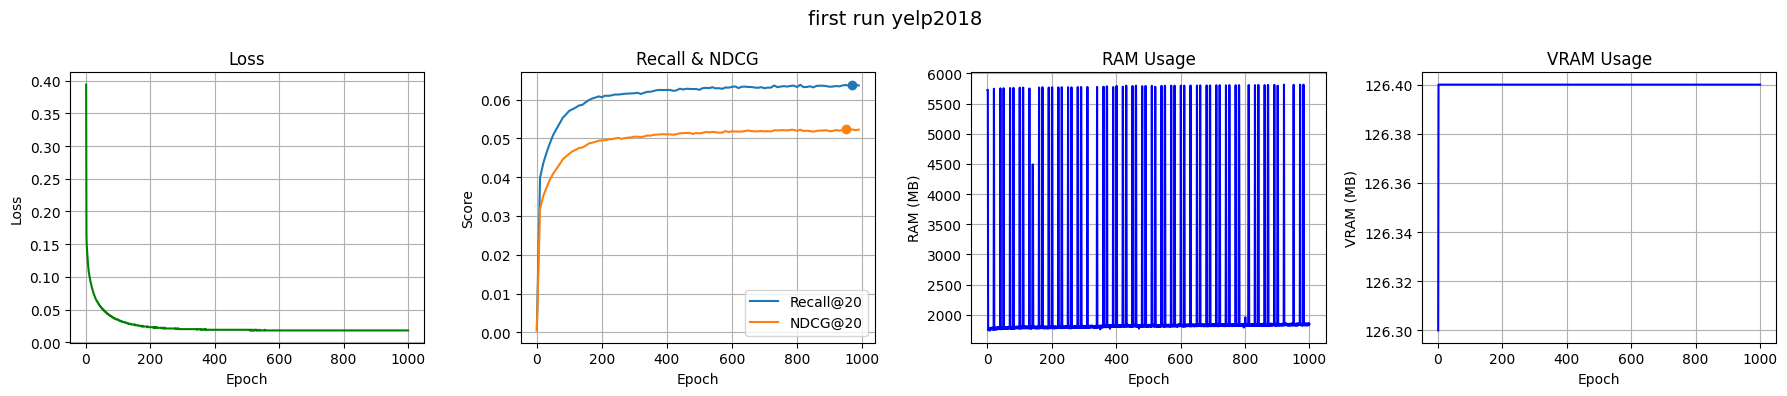

In [26]:
plot_all_metrics("performance/yelp2018/first.txt", "metrics/yelp2018/04-07-02h16m06s--lgn", "yelp2018")

Average System RAM : 1977.13 MB
Average System VRAM: 126.40 MB
Best Recall@20: 0.063877 @ epoch 970
Best NDCG@20 : 0.052328 @ epoch 950


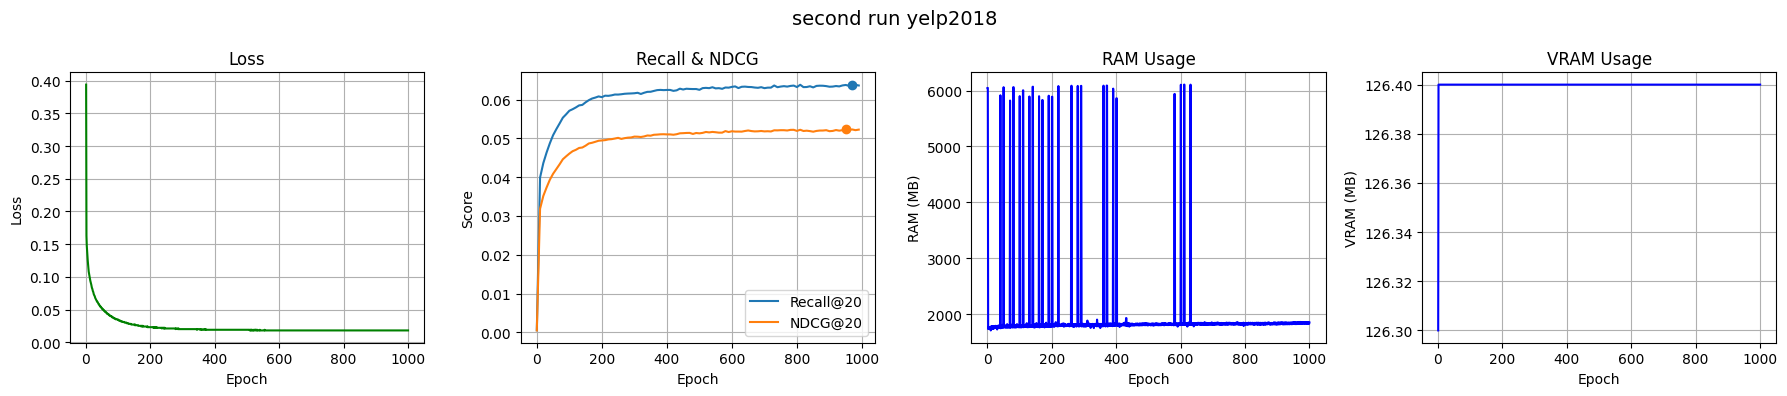

In [27]:
plot_all_metrics("performance/yelp2018/second.txt", "metrics/yelp2018/04-07-02h11m23s--lgn", "yelp2018")

Average System RAM : 1875.24 MB
Average System VRAM: 126.40 MB
Best Recall@20: 0.063877 @ epoch 970
Best NDCG@20 : 0.052329 @ epoch 950


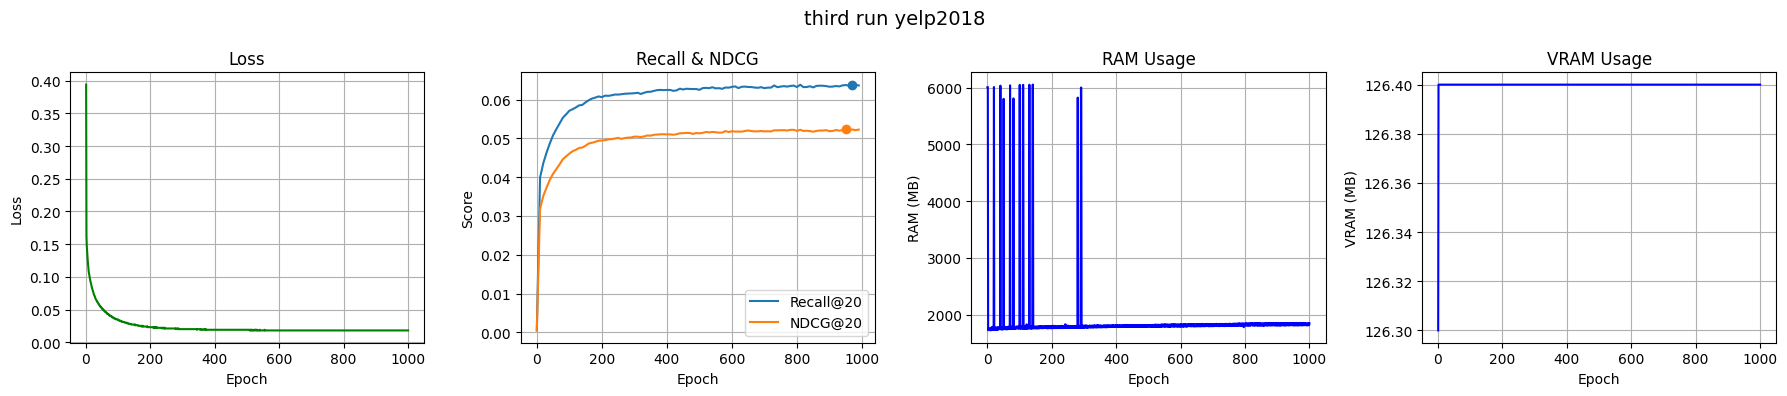

In [28]:
plot_all_metrics("performance/yelp2018/third.txt", "metrics/yelp2018/04-07-02h13m32s--lgn", "yelp2018")

**AmazonBook**

Best Recall@20: 0.041009 @ epoch 20
Best NDCG@20 : 0.031567 @ epoch 20


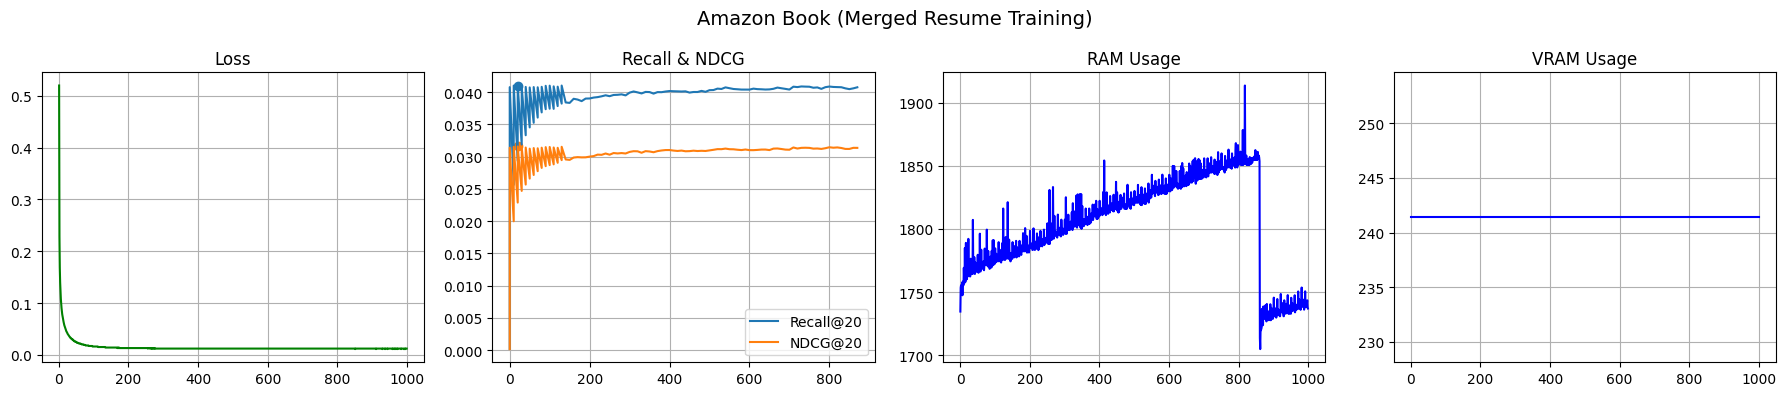

In [29]:
plot_all_metrics_for_amazon(
    log_txt_path="performance/amazonbook/first.txt",
    tensorboard_paths=[
        "metrics/amazonbook/first/04-07-16h59m22s--lgn",
        "metrics/amazonbook/first/04-09-01h23m53s--lgn"
    ],
    name="Amazon Book"
)

Best Recall@20: 0.041015 @ epoch 10
Best NDCG@20 : 0.031564 @ epoch 20


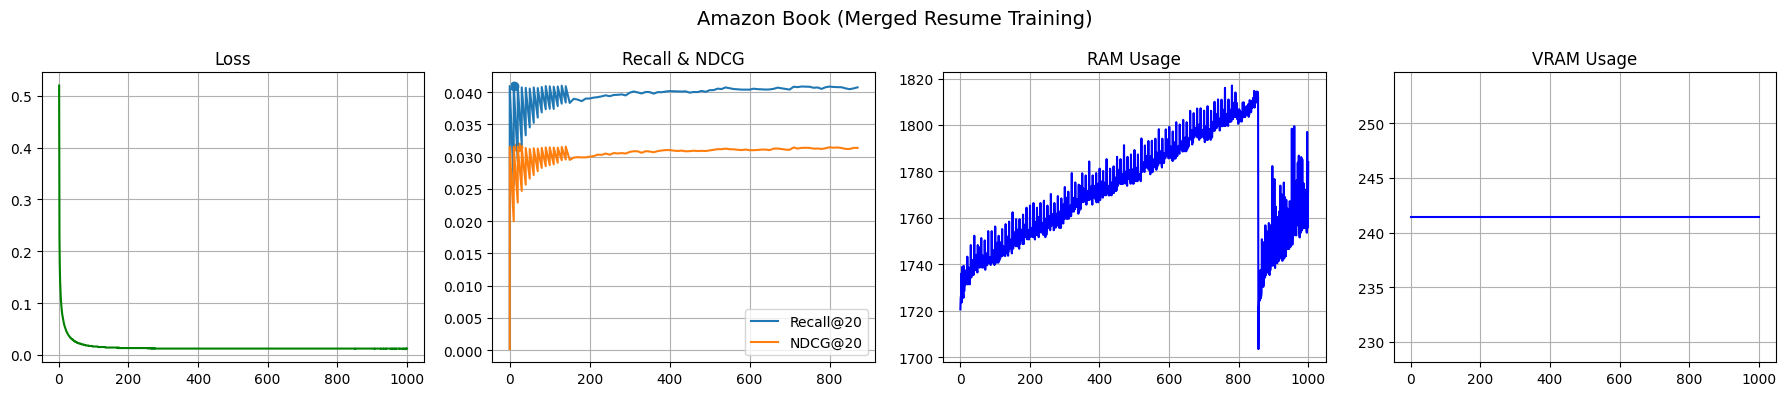

In [30]:
plot_all_metrics_for_amazon(
    log_txt_path="performance/amazonbook/second.txt",
    tensorboard_paths=[
        "metrics/amazonbook/second/04-07-16h57m37s--lgn",
        "metrics/amazonbook/second/04-09-01h22m56s--lgn"
    ],
    name="Amazon Book"
)

Best Recall@20: 0.041009 @ epoch 20
Best NDCG@20 : 0.031567 @ epoch 20


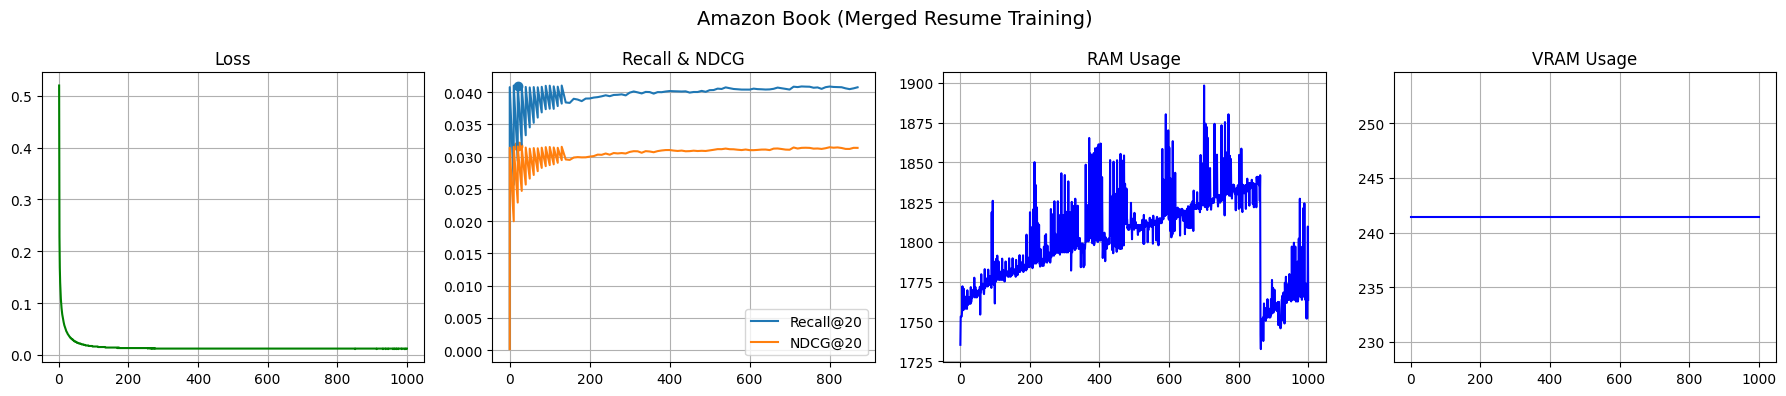

In [31]:
plot_all_metrics_for_amazon(
    log_txt_path="performance/amazonbook/third.txt",
    tensorboard_paths=[
        "metrics/amazonbook/third/04-07-16h56m05s--lgn",
        "metrics/amazonbook/third/04-09-01h24m59s--lgn"
    ],
    name="Amazon Book"
)

**Gowalla**

Average System RAM : 1699.27 MB
Average System VRAM: 108.80 MB
Best Recall@20: 0.182057 @ epoch 810
Best NDCG@20 : 0.154196 @ epoch 970


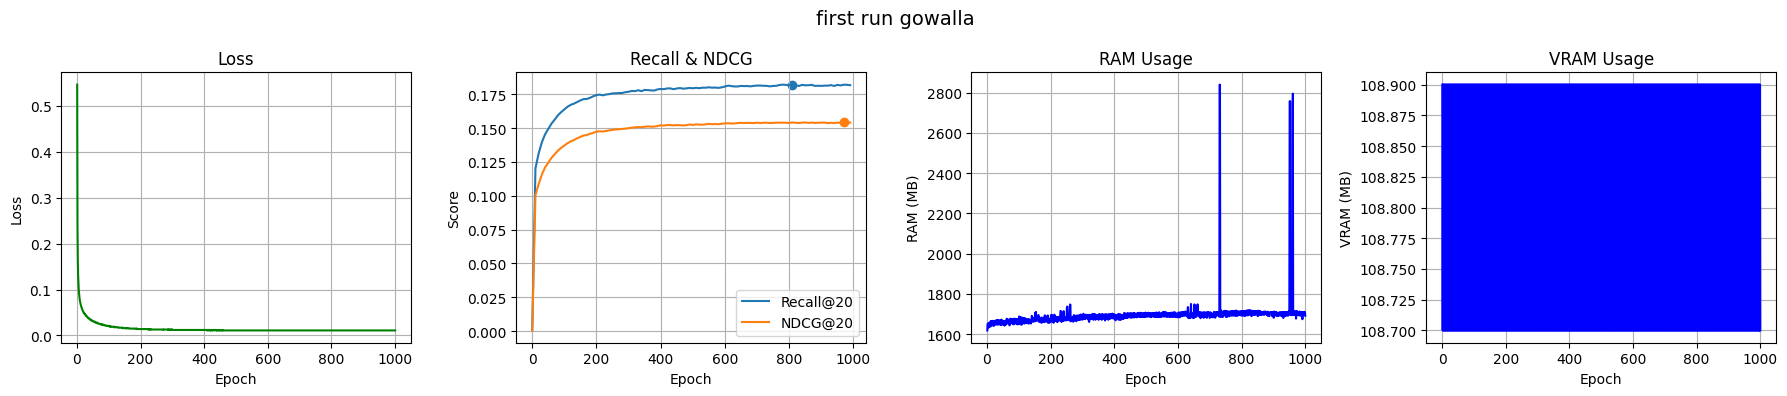

In [32]:
plot_all_metrics("performance/gowalla/first.txt", "metrics/gowalla/04-06-14h07m29s--lgn", "gowalla")

Average System RAM : 1765.88 MB
Average System VRAM: 108.80 MB
Best Recall@20: 0.182057 @ epoch 810
Best NDCG@20 : 0.154195 @ epoch 970


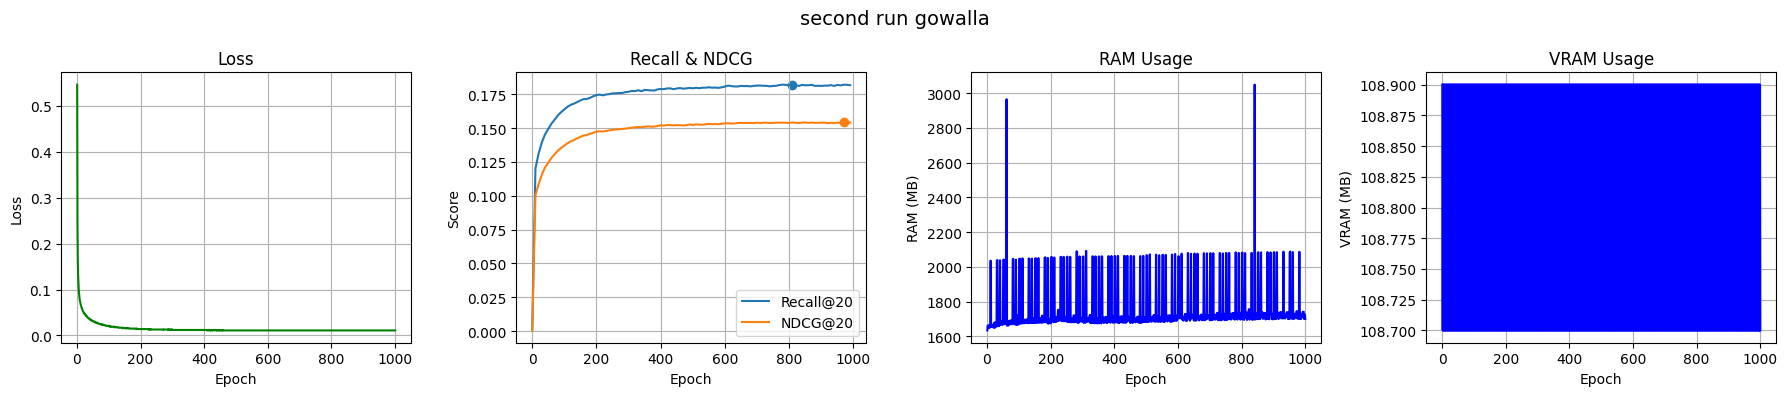

In [33]:
plot_all_metrics("performance/gowalla/second.txt", "metrics/gowalla/04-06-14h11m21s--lgn", "gowalla")

Average System RAM : 1691.50 MB
Average System VRAM: 108.80 MB
Best Recall@20: 0.182057 @ epoch 810
Best NDCG@20 : 0.154196 @ epoch 970


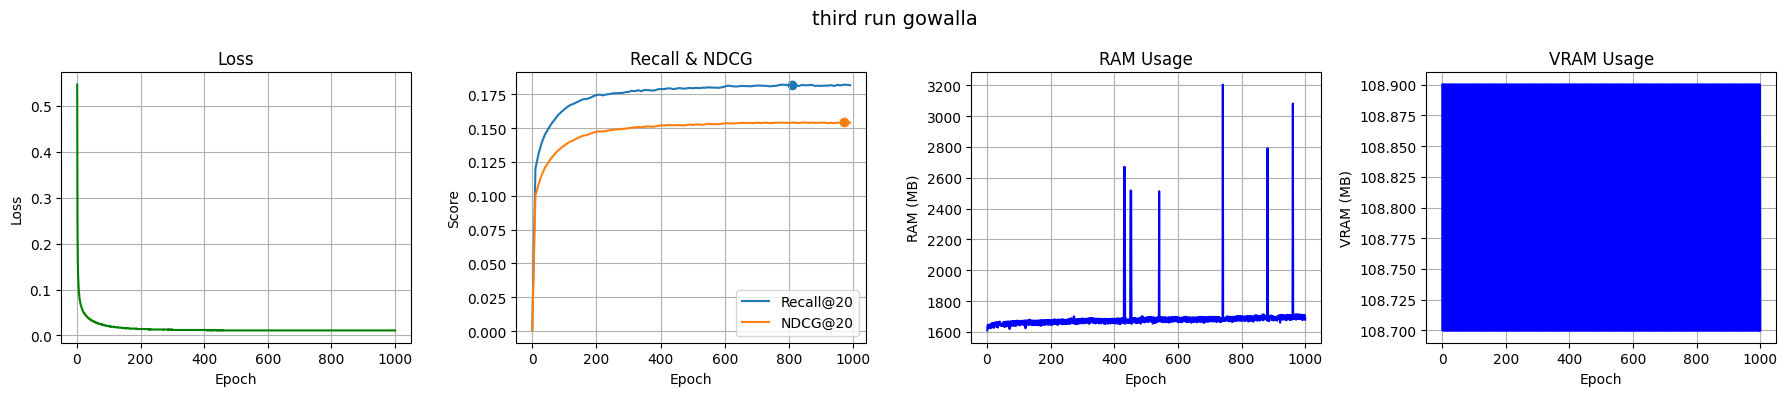

In [34]:
plot_all_metrics("performance/gowalla/third.txt", "metrics/gowalla/04-06-14h08m41s--lgn", "gowalla")

**Movielen**

Average System RAM : 1697.09 MB
Average System VRAM: 47.80 MB
Best Recall@20: 0.257638 @ epoch 190
Best NDCG@20 : 0.242705 @ epoch 190


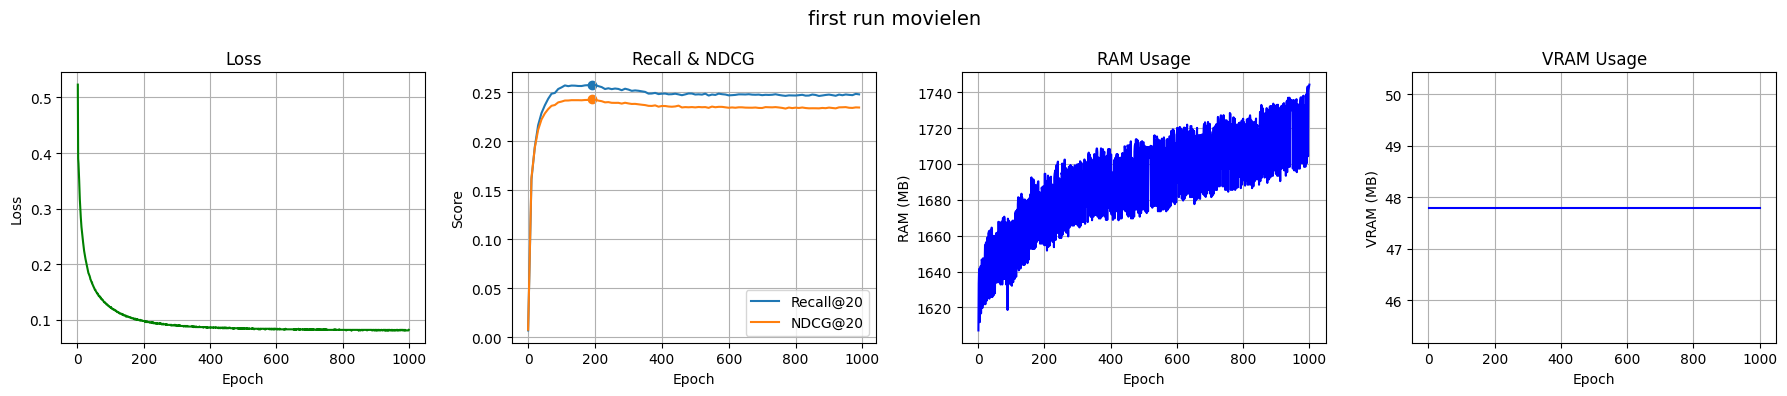

In [35]:
plot_all_metrics("performance/movielen/first.txt", "metrics/movielen/04-09-07h49m03s--lgn", "movielen")

Average System RAM : 1714.49 MB
Average System VRAM: 47.80 MB
Best Recall@20: 0.257638 @ epoch 190
Best NDCG@20 : 0.242704 @ epoch 190


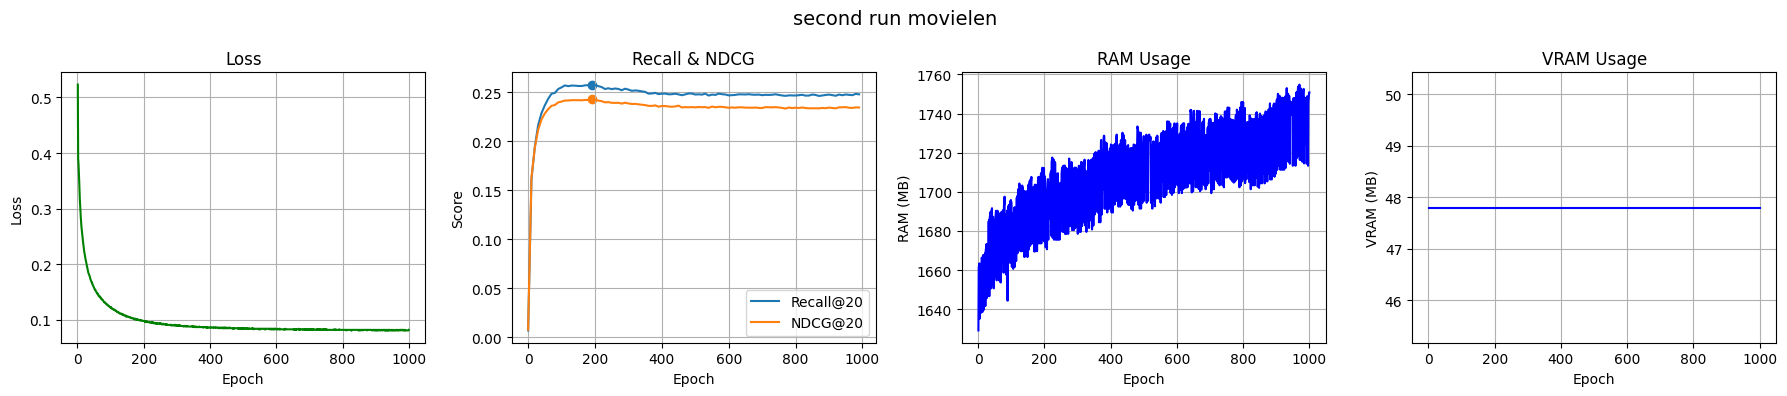

In [36]:
plot_all_metrics("performance/movielen/second.txt", "metrics/movielen/04-09-07h47m41s--lgn", "movielen")

Average System RAM : 1695.99 MB
Average System VRAM: 47.80 MB
Best Recall@20: 0.257638 @ epoch 190
Best NDCG@20 : 0.242706 @ epoch 190


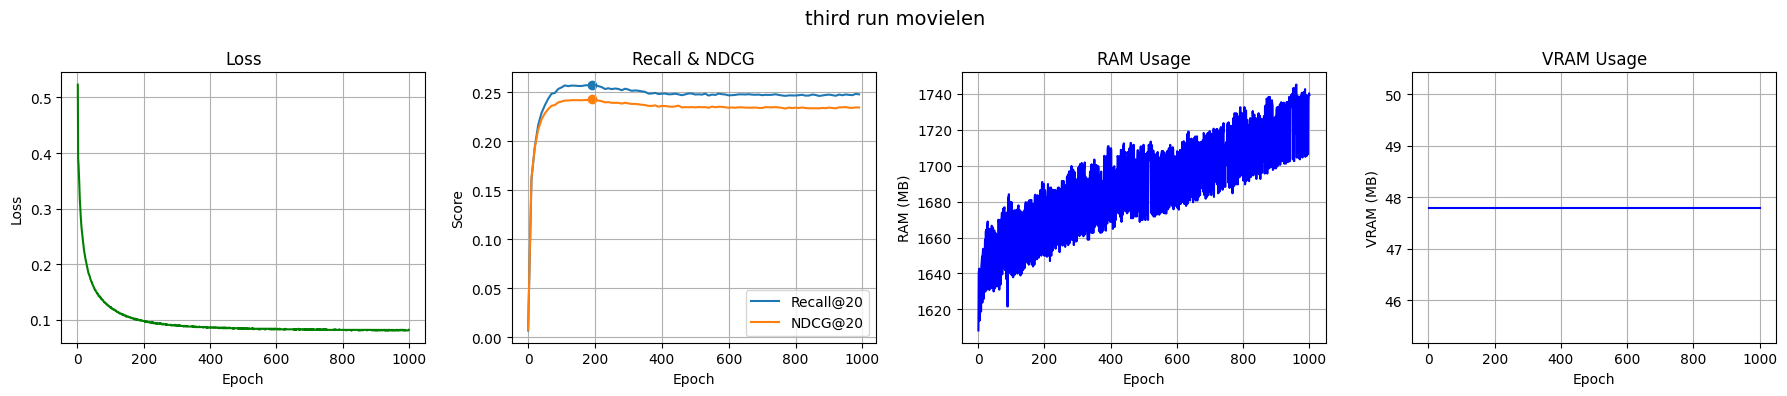

In [37]:
plot_all_metrics("performance/movielen/third.txt", "metrics/movielen/04-09-07h50m14s--lgn", "movielen")

**GitStar**

Average System RAM : 1743.34 MB
Average System VRAM: 64.40 MB
Best Recall@20: 0.044454 @ epoch 10
Best NDCG@20 : 0.020112 @ epoch 10


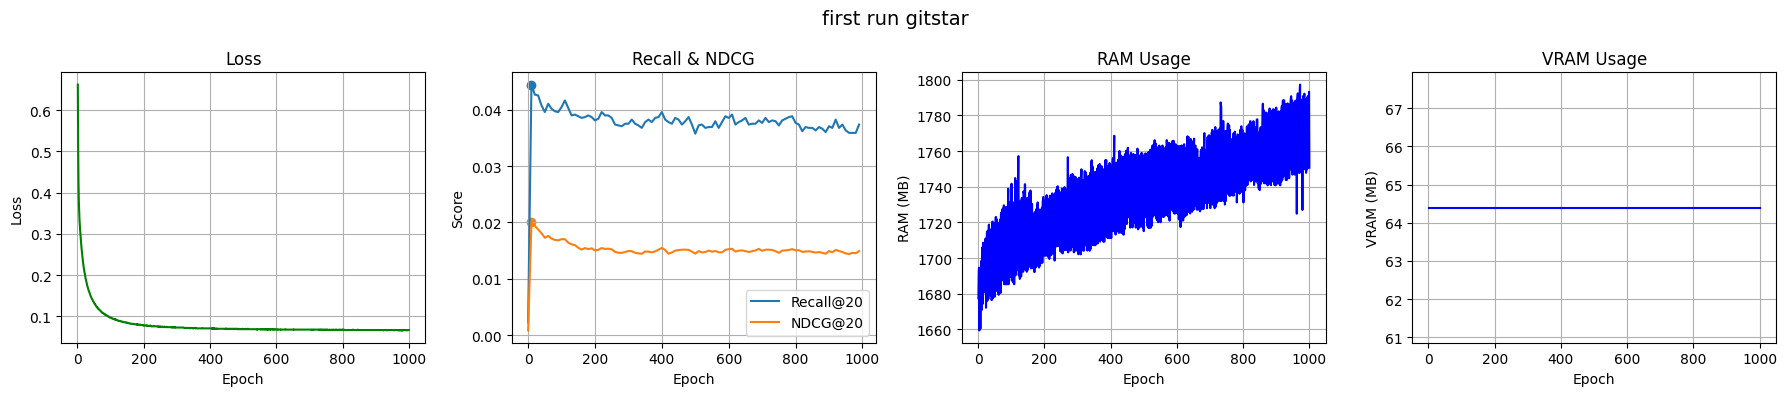

In [38]:
plot_all_metrics("performance/gitstar/first.txt", "metrics/gitstar/04-09-14h41m29s--lgn", "gitstar")

Average System RAM : 1733.70 MB
Average System VRAM: 64.40 MB
Best Recall@20: 0.044454 @ epoch 10
Best NDCG@20 : 0.020112 @ epoch 10


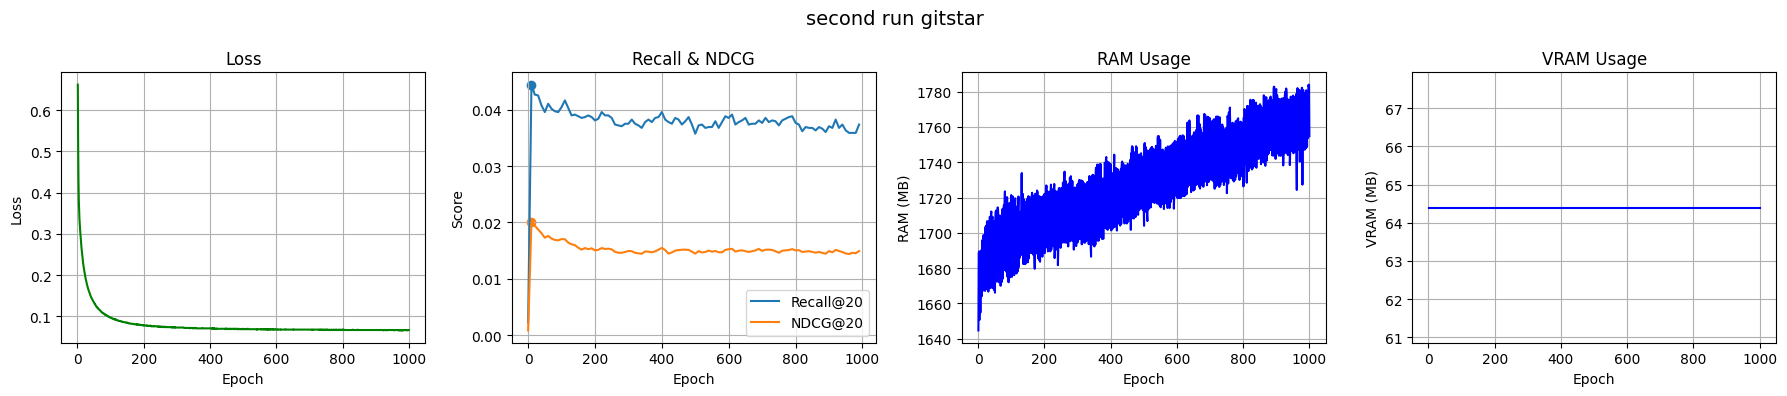

In [39]:
plot_all_metrics("performance/gitstar/second.txt", "metrics/gitstar/04-09-14h41m02s--lgn", "gitstar")

Average System RAM : 1777.84 MB
Average System VRAM: 64.40 MB
Best Recall@20: 0.044454 @ epoch 10
Best NDCG@20 : 0.020112 @ epoch 10


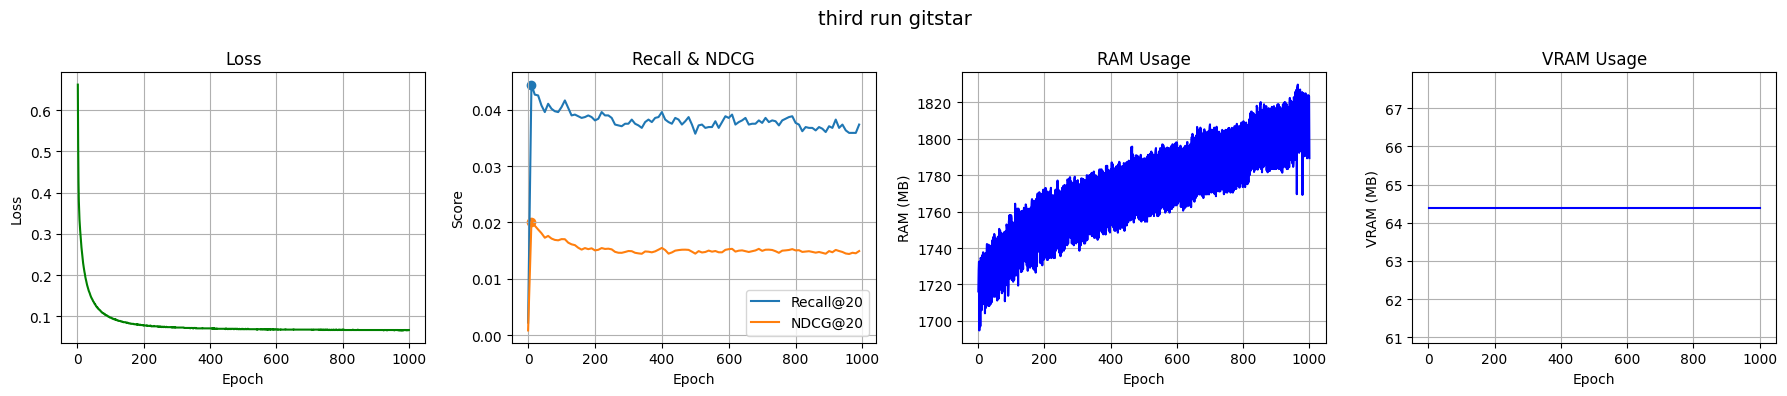

In [40]:
plot_all_metrics("performance/gitstar/third.txt", "metrics/gitstar/04-09-14h39m10s--lgn", "gitstar")